In [5]:
%load_ext autoreload
%autoreload 2

In [1]:
print("hje")

hje


In [5]:
import torch
torch.rand(5,1,3,2).shape[2:]

torch.Size([3, 2])

In [6]:
from PIL import Image
from pathlib import Path
from src.models.lit_vgg import LitVGG
import torchvision
from src.models.gradcam import GradCAM

image = Image.open(next(Path("data/train").rglob("*.jpg")))

lit_vgg = LitVGG.load_from_checkpoint(
    "checkpoints/vgg19_bn/vgg19_bn-epoch=7-valid_loss=0.31.ckpt",
    weights_only=False
)

gradcam = GradCAM(lit_vgg.model, lit_vgg.model.vgg.features[-4])

W0413 21:11:37.432000 15948 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [43]:
next(Path("data/train").rglob("*.jpg"))

WindowsPath('data/train/glioma/Tr-gl_1.jpg')

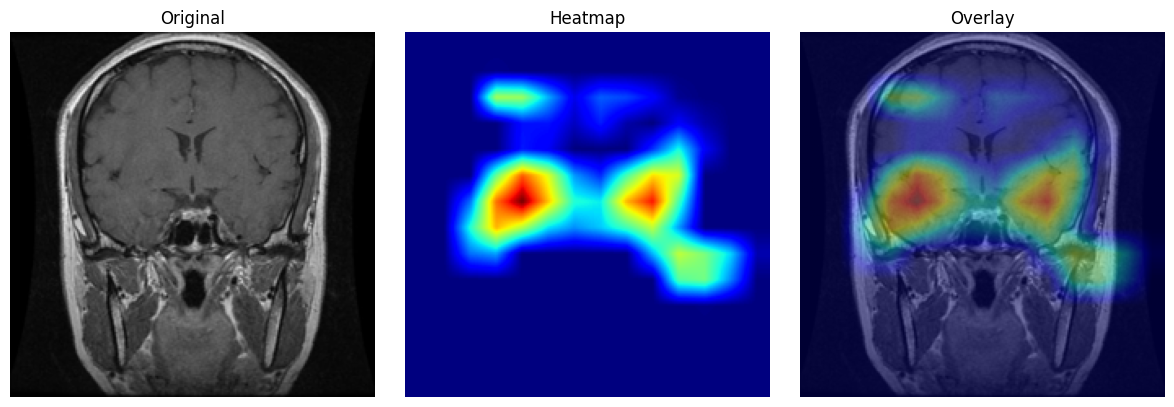

In [11]:
import matplotlib.pyplot as plt
fig  = gradcam.visualize(img_path=next(Path("data/train/pituitary").rglob("*.jpg")))

In [ ]:
model = lit_vgg.model
x = model.transforms(image)
cam  = gradcam.generate(x)
gradients = gradcam.gradients

# set model to eval and place input to same device
model.eval()
device = next(model.parameters()).device
x = x.to(device)

# make sure parameters are unfrozen
for param in model.parameters():
    param.requires_grad = True
logits = model(x)

# if no class provided, use predicted class
# if class_idx is None:
class_idx=logits.argmax(dim=1)

# backpropagation from target class
model.zero_grad()
logits[0, class_idx].backward()

# calculate gradcam
weights = gradients.mean(dim=[2,3], keepdim=True)
cam = (weights*activations).sum(dim=1, keepdim=True)
cam = torch.relu(cam)

cam

AttributeError: 'VGGModel' object has no attribute 'model'

In [36]:
lit_vgg.model.vgg.features[-5:]

Sequential(
  (48): ReLU(inplace=True)
  (49): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (50): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (51): ReLU(inplace=True)
  (52): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [11]:
lit_vgg.model(img_test.to("cuda")).cpu()

tensor([[ 3.7711, -1.4053, -2.8846, -3.8170]], grad_fn=<ToCopyBackward0>)

In [1]:
print("h")

h


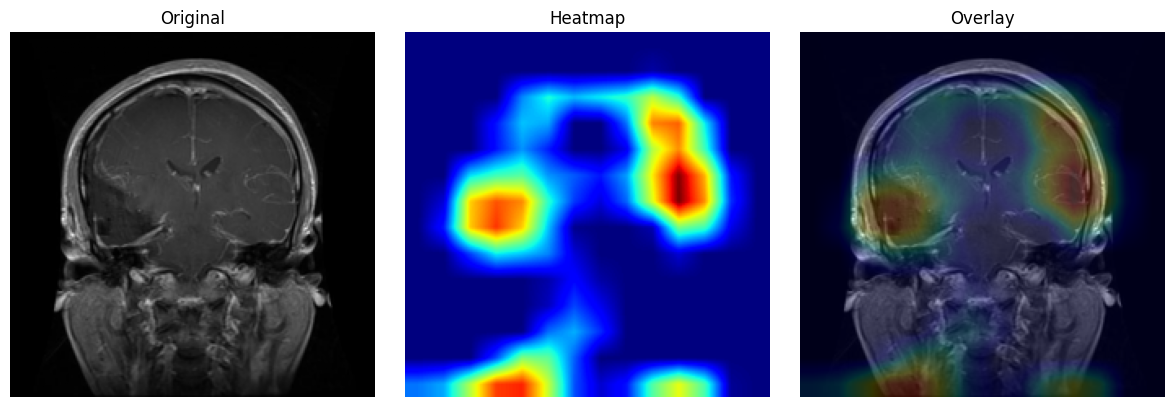

In [32]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

cam = gradcam.generate(img_test)
cam = F.interpolate(cam, size=img_test.shape[2:], mode="bilinear", align_corners=False)
cam = cam.squeeze().detach().cpu().numpy()
cam = (cam-cam.min())/(cam.max()-cam.min())

img = np.array(image.convert("RGB").resize((img_test.shape[3], img_test.shape[2])))/255.0

heatmap = plt.cm.jet(cam)[:,:,:3]

alpha = 0.2
overlay = alpha*heatmap + (1-alpha)*img

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(heatmap)
axes[1].set_title("Heatmap")
axes[2].imshow(overlay)
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
plt.cm.jet(cam).shape

(224, 224, 4)

In [16]:
import torchvision
data_transforms = torchvision.models.VGG19_BN_Weights.DEFAULT.transforms()

In [20]:
import numpy as np
np.array(image).shape

(512, 512)

In [39]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transforms = torchvision.models.VGG19_BN_Weights.DEFAULT.transforms()

train_dir = "data/train"
train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
from PIL import Image
from pathlib import Path



In [1]:
import torch
print(torch.cuda.is_available())

True


In [1]:
!nvidia-smi

Mon Apr 13 17:12:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   40C    P0             13W /  100W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
print(torch.cuda.get_device_name(0)) # Should show your dedicated GPU

: 

In [30]:
for image, label in train_dataloader:
    print(image.shape)
    break

torch.Size([64, 3, 224, 224])


In [34]:
import torch

out = model(image)

In [36]:
pred = model(image[[0]])

In [38]:
pred.argmax(dim=1)

tensor([0])

In [ ]:
data_transforms = torchvision.models.VGG19_BN_Weights.DEFAULT.transforms()